# Two ways to count a loss of separation

The estimator counts a loss of separation in two ways. It reports both.

| Name | What it divides | What it divides by |
|---|---|---|
| `p_los_run` | the runs that have a loss | all the runs |
| `p_los_ac` | the aircraft that lose separation | all the aircraft that fly |
| `mean_k` | the pairs that lose separation | all the runs |

`p_los_ac` is the headline value. It follows Blom and Bakker (2015), who normalise per aircraft.

A loss of separation is always between **two** aircraft. One loss therefore gives one pair
(`K = 1`) and two aircraft (`A = 2`).

This notebook shows four things:

1. With two aircraft, the two values are the same.
2. With three aircraft, the two values are different. One aircraft can stay clear.
3. Two runs can have the same `p_los_run` and different `p_los_ac` and `mean_k`.
4. With more aircraft, `p_los_run` goes to 1. `p_los_ac` does not.

In [1]:
%matplotlib inline
from dataclasses import replace

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 130

from opencdarr import geo
from opencdarr.cd import StateBased
from opencdarr.config import (
    Config,
    ConflictConfig,
    MethodsConfig,
    ScenarioConfig,
    SimulationConfig,
)
from opencdarr.estimate.montecarlo import estimate_p_los
from opencdarr.fleet import Agent, run_fleet
from opencdarr.performance import M600
from opencdarr.scenario import create_conflict, pairwise, sample_pairwise
from opencdarr.state import AircraftState
from opencdarr.viz import extract_tracks

RPZ = 50.0            # the protected zone radius [m]
SPEED = 10.0          # the ground speed of every aircraft [m/s]

# the run settings. There is no resolver, thus the aircraft do not avoid each other.
RUN = dict(rpz=RPZ, t_lookahead=120.0, dt=1.0, detector=StateBased(),
           resolver=None, recovery=None, t_max=200.0, done_timeout=10.0)

## 1. Two aircraft: the two values agree

A pairwise run has two aircraft. If one aircraft loses separation, the other aircraft also loses
separation. Thus `A` is 2 and `N` is 2, and `A / N` is 1.

The two values are therefore equal. This is important: it keeps every pairwise result the same.

In [2]:
def config(n_encounters: int) -> Config:
    """The encounter distribution. `dcpa_max` is 2 x rpz, thus about half the runs have a loss."""
    return Config(
        seed=0, n_encounters=n_encounters,
        scenario=ScenarioConfig("M600", SPEED, 2 * RPZ, 60.0),
        conflict=ConflictConfig(RPZ, 120.0),
        methods=MethodsConfig("statebased", None, None, 1.05, False),
        simulation=SimulationConfig(1.0, 300.0, 10.0),
    )


two = estimate_p_los(pairwise(M600), config(600), StateBased(), None, None)

print(f"aircraft that flew   : {two.sum_n}")
print(f"aircraft with a loss : {two.sum_a}")
print(f"p_los_run = {two.p_los_run:.4f}")
print(f"p_los_ac  = {two.p_los_ac:.4f}")
print(f"mean_k    = {two.mean_k:.4f}")
print(f"\nthe three values agree: {two.p_los_run == two.p_los_ac == two.mean_k}")

aircraft that flew   : 1200
aircraft with a loss : 636
p_los_run = 0.5300
p_los_ac  = 0.5300
mean_k    = 0.5300

the three values agree: True


## 2. Three aircraft: one aircraft stays clear

Now add a third aircraft. Aircraft **A** and aircraft **B** cross. They lose separation. Aircraft
**C** flies parallel to A, 400 m to the east. C keeps its separation for the full run.

This is the case where the two values disagree.

In [3]:
own = AircraftState(id="A", lat=52.0, lon=4.0, trk=0.0, gs=SPEED)
intr = create_conflict(own, intr_id="B", dpsi=90.0, dcpa=0.0, tlos=60.0, rpz=RPZ)
east = geo.forward(52.0, 4.0, 90.0, 400.0)          # 400 m east of A
clear = AircraftState(id="C", lat=east[0], lon=east[1], trk=0.0, gs=SPEED)

fleet = [Agent(s, M600) for s in (own, intr, clear)]
out = run_fleet(fleet, record=True, **RUN)

n_aircraft = len(fleet)
print(f"K (pairs with a loss)    : {out.n_los_pairs}")
print(f"A (aircraft with a loss) : {out.n_los_aircraft}")
print(f"N (aircraft that flew)   : {n_aircraft}")
print(f"closest approach         : {out.min_sep:.1f} m")
print()
print(f"p_los_run = {float(out.los):.4f}   <- the run has a loss, thus 1")
print(f"p_los_ac  = {out.n_los_aircraft} / {n_aircraft} = "
      f"{out.n_los_aircraft / n_aircraft:.4f}   <- C is not in the count")

K (pairs with a loss)    : 1
A (aircraft with a loss) : 2
N (aircraft that flew)   : 3
closest approach         : 0.0 m

p_los_run = 1.0000   <- the run has a loss, thus 1
p_los_ac  = 2 / 3 = 0.6667   <- C is not in the count


The figure below shows why the two values are different. The right panel gives the distance of
each **pair**. Three aircraft make three pairs: A-B, A-C and B-C.

Count the pairs that go below rpz and you have `K`. Collect the aircraft in those pairs and you
have `A`.

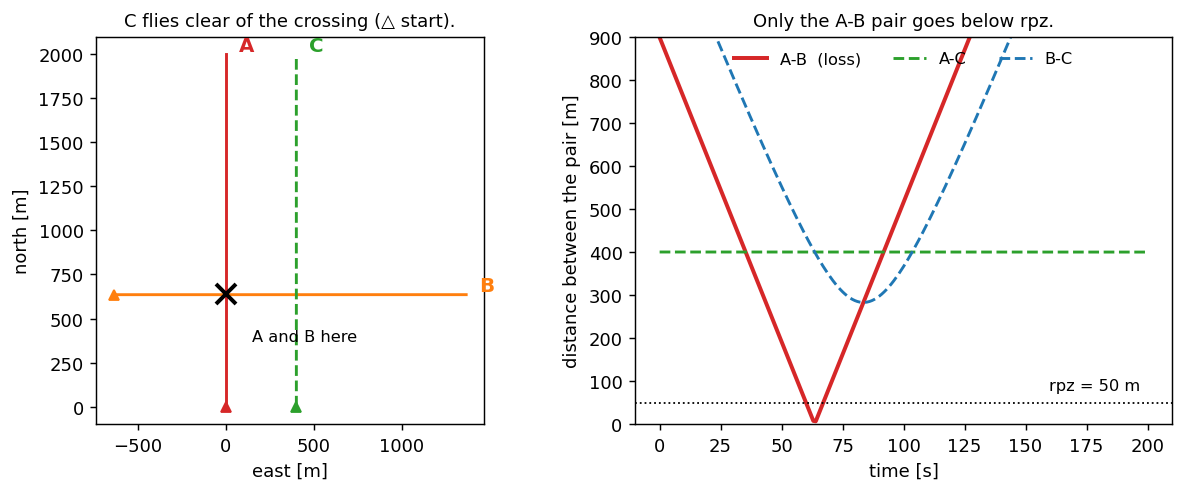

In [4]:
t = extract_tracks(out)
breach = int(np.argmin(t.separation))              # the tick of the closest approach

# the distance of every pair, at each tick. A pair has a loss if its line goes below rpz. Count
# the lines that go below rpz and you have K. Collect the aircraft in those pairs and you have A.
xy = np.stack(t.tracks)                            # (aircraft, time, 2)
pairs = [(i, j) for i in range(len(xy)) for j in range(i + 1, len(xy))]
gaps = {f"{t.ids[i]}-{t.ids[j]}": np.linalg.norm(xy[i] - xy[j], axis=-1) for i, j in pairs}

colours = {"A": "tab:red", "B": "tab:orange", "C": "tab:green"}
pair_colours = {"A-B": "tab:red", "A-C": "tab:green", "B-C": "tab:blue"}
fig, (ax, ax_gap) = plt.subplots(1, 2, figsize=(9.6, 3.9))

for name, track in zip(t.ids, t.tracks):
    ax.plot(track[:, 0], track[:, 1], color=colours[name], lw=1.6,
            ls="--" if name == "C" else "-")
    ax.plot(track[0, 0], track[0, 1], marker="^", ms=6, color=colours[name])
    ax.annotate(name, track[-1], textcoords="offset points", xytext=(7, 2),
                color=colours[name], fontsize=11, weight="bold")

centre = np.mean([track[breach] for name, track in zip(t.ids, t.tracks)
                  if name in ("A", "B")], axis=0)
ax.plot(*centre, marker="x", ms=11, mew=2.2, color="k")
ax.annotate("A and B here", centre, textcoords="offset points", xytext=(14, -26), fontsize=9)
ax.set_xlabel("east [m]")
ax.set_ylabel("north [m]")
ax.set_title("C flies clear of the crossing (△ start).", fontsize=10)
ax.set_aspect("equal")

for name, line in gaps.items():
    lost = line.min() < RPZ
    ax_gap.plot(t.times, line, color=pair_colours[name], lw=2.2 if lost else 1.6,
                ls="-" if lost else "--", label=f"{name}{'  (loss)' if lost else ''}")
ax_gap.axhline(RPZ, color="k", lw=1.0, ls=":")
ax_gap.annotate(f"rpz = {RPZ:.0f} m", (t.times[-1], RPZ), textcoords="offset points",
                xytext=(-4, 7), ha="right", fontsize=9)
ax_gap.set_xlabel("time [s]")
ax_gap.set_ylabel("distance between the pair [m]")
ax_gap.set_title("Only the A-B pair goes below rpz.", fontsize=10)
ax_gap.set_ylim(0, 900)
ax_gap.legend(frameon=False, fontsize=9, loc="upper center", ncol=3)

fig.tight_layout()
plt.show()

**Read the two values.**

`p_los_run` gives **1.0**. The run contains a loss, thus the run counts as a full failure. The
value does not show that C is safe. It cannot show it. A run has a loss, or it does not.

`p_los_ac` gives **0.667**. Two aircraft of three lose separation. The value gives credit to C.

This is the difference in one line:

- `p_los_run` is a property of the **run**.
- `p_los_ac` is a property of the **aircraft**.

A loss always involves two aircraft. Thus a larger fleet makes `A / N` smaller for the same loss.
With 8 aircraft, the same single loss gives `p_los_ac = 2 / 8 = 0.25`.

The next section keeps the same three aircraft, but gives them a second loss.

## 3. Three aircraft in a chain

Now change the geometry. Aircraft **B** flies through the middle. **A** crosses B first. **C**
crosses B later, from the other side. A and C stay 800 m apart for the full run.

The run therefore has two losses: A with B, and B with C. A and C keep their separation.

In [5]:
mid = AircraftState(id="B", lat=52.0, lon=4.0, trk=0.0, gs=SPEED)
first = create_conflict(mid, intr_id="A", dpsi=90.0, dcpa=0.0, tlos=50.0, rpz=RPZ, side=1)
later = create_conflict(mid, intr_id="C", dpsi=270.0, dcpa=0.0, tlos=130.0, rpz=RPZ, side=-1)

chain = [Agent(s, M600) for s in (first, mid, later)]
out_chain = run_fleet(chain, record=True, **dict(RUN, t_max=300.0))

print(f"K (pairs with a loss)    : {out_chain.n_los_pairs}")
print(f"A (aircraft with a loss) : {out_chain.n_los_aircraft}")
print(f"N (aircraft that flew)   : {len(chain)}")
print()
print(f"p_los_run = {float(out_chain.los):.4f}")
print(f"p_los_ac  = {out_chain.n_los_aircraft} / {len(chain)} = "
      f"{out_chain.n_los_aircraft / len(chain):.4f}")
print(f"mean_k    = {out_chain.n_los_pairs:.4f}   <- this run has two losses, not one")

K (pairs with a loss)    : 2
A (aircraft with a loss) : 3
N (aircraft that flew)   : 3

p_los_run = 1.0000
p_los_ac  = 3 / 3 = 1.0000
mean_k    = 2.0000   <- this run has two losses, not one


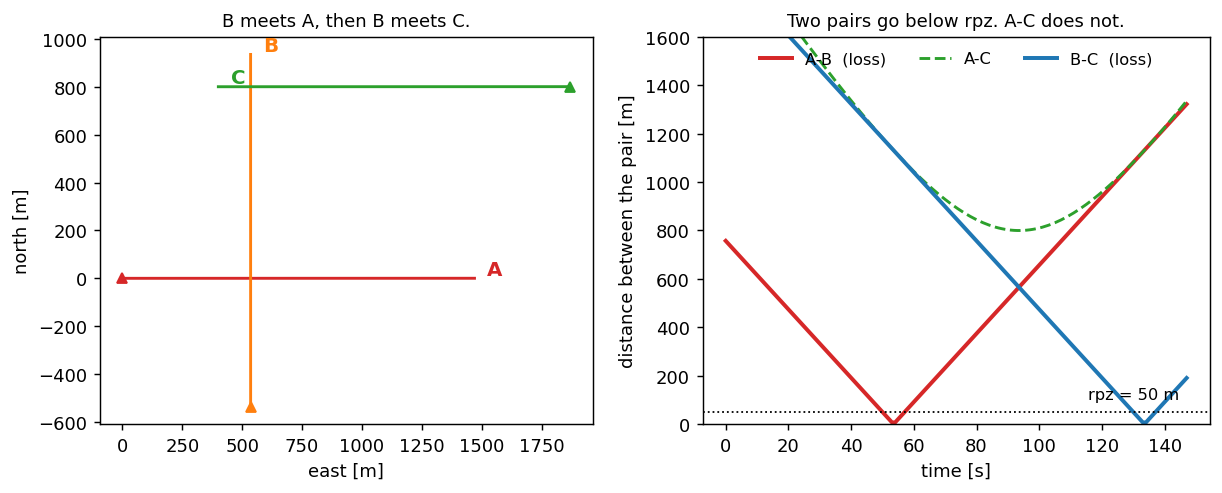

In [6]:
tc = extract_tracks(out_chain)
xyc = np.stack(tc.tracks)
gaps_c = {f"{tc.ids[i]}-{tc.ids[j]}": np.linalg.norm(xyc[i] - xyc[j], axis=-1)
          for i in range(len(xyc)) for j in range(i + 1, len(xyc))}

fig, (ax, ax_gap) = plt.subplots(1, 2, figsize=(9.6, 3.9))

for name, track in zip(tc.ids, tc.tracks):
    ax.plot(track[:, 0], track[:, 1], color=colours[name], lw=1.6)
    ax.plot(track[0, 0], track[0, 1], marker="^", ms=6, color=colours[name])
    ax.annotate(name, track[-1], textcoords="offset points", xytext=(7, 2),
                color=colours[name], fontsize=11, weight="bold")
ax.set_xlabel("east [m]")
ax.set_ylabel("north [m]")
ax.set_title("B meets A, then B meets C.", fontsize=10)
ax.set_aspect("equal")

for name, line in gaps_c.items():
    lost = line.min() < RPZ
    ax_gap.plot(tc.times, line, color=pair_colours[name], lw=2.2 if lost else 1.6,
                ls="-" if lost else "--", label=f"{name}{'  (loss)' if lost else ''}")
ax_gap.axhline(RPZ, color="k", lw=1.0, ls=":")
ax_gap.annotate(f"rpz = {RPZ:.0f} m", (tc.times[-1], RPZ), textcoords="offset points",
                xytext=(-4, 7), ha="right", fontsize=9)
ax_gap.set_xlabel("time [s]")
ax_gap.set_ylabel("distance between the pair [m]")
ax_gap.set_title("Two pairs go below rpz. A-C does not.", fontsize=10)
ax_gap.set_ylim(0, 1600)
ax_gap.legend(frameon=False, fontsize=9, loc="upper center", ncol=3)

fig.tight_layout()
plt.show()

## 4. Compare the two runs: how `K` and `A` count

The two runs have the same three aircraft. They have the same `p_los_run`. But they are not
equally bad.

| | Pairs with a loss | `K` | `A` | `N` | `p_los_run` | `p_los_ac` | `mean_k` |
|---|---|---|---|---|---|---|---|
| Run 1 — one aircraft clear | A-B | 1 | 2 | 3 | 1.000 | **0.667** | **1** |
| Run 2 — a chain | A-B, B-C | 2 | 3 | 3 | 1.000 | **1.000** | **2** |

**How to count `K`.** `K` is the number of *pairs* that go below rpz. Run 1 has one pair. Run 2 has
two pairs. Three aircraft make three pairs in total, thus `K` can be 0, 1, 2 or 3.

**How to count `A`.** `A` is the number of *aircraft* that are in at least one of those pairs. In
run 2, aircraft B is in two losing pairs. `A` counts B **one** time. `A` is an indicator for each
aircraft: the aircraft loses separation, or it does not. The count of losses stays in `K`.

**What each value shows.**

- `p_los_run` gives 1.000 for both runs. It cannot tell them apart. A run has a loss, or it does
  not, and both runs have one.
- `p_los_ac` gives 0.667 and 1.000. It separates the two runs, because run 1 keeps one aircraft
  clear and run 2 does not.
- `mean_k` gives 1 and 2. Run 2 has two times the loss of run 1.

Run 2 also shows a limit of `p_los_ac`. All three aircraft lose separation, thus `p_los_ac` is at
its maximum. It cannot become worse. Only `mean_k` continues to increase. Use `mean_k` when the
fleet is dense and almost every aircraft is involved.

### `K` does not tell you `A`

The shape of the losses sets `A`. The examples below all have `K = 3` in a fleet of nine aircraft.
They do not have the same `A`.

In [7]:
shapes = {
    "chain     a-b, b-c, c-d": {("a", "b"), ("b", "c"), ("c", "d")},
    "triangle  a-b, b-c, a-c": {("a", "b"), ("b", "c"), ("a", "c")},
    "disjoint  a-b, c-d, e-f": {("a", "b"), ("c", "d"), ("e", "f")},
}
fleet_size = 9

print(f"{'shape':26} {'K':>2} {'A':>3}   p_los_ac   p_los_run")
for name, los_pairs in shapes.items():
    k = len(los_pairs)
    # exactly how the simulator counts A: the aircraft in at least one losing pair
    a = len({ac for pair in los_pairs for ac in pair})
    print(f"{name:26} {k:2d} {a:3d}   {a / fleet_size:8.3f}   {1.0:9.3f}")

shape                       K   A   p_los_ac   p_los_run
chain     a-b, b-c, c-d     3   4      0.444       1.000
triangle  a-b, b-c, a-c     3   3      0.333       1.000
disjoint  a-b, c-d, e-f     3   6      0.667       1.000


The three rows have the same `K` and the same `p_los_run`. The value of `A` changes from 3 to 6,
thus `p_los_ac` changes from 0.333 to 0.667.

A triangle puts all the loss on three aircraft. Three separate pairs put the same number of losses
on six aircraft. The danger to each aircraft is therefore different, but `K` cannot show it.

This is why the simulator keeps the **set** of losing pairs and not only a count. You cannot
calculate `A` from `K`. You must count the aircraft in the pairs.

## 5. More aircraft: `p_los_run` goes to 1

The last section uses one run. Now use many runs, and make the fleet larger.

Each run has `m` pairs. The pairs are far apart, thus they do not interact. Every pair has the same
risk. This keeps the comparison clean. The airspace does not become more dangerous. It only becomes
larger.

In [8]:
def independent_pairs(m: int):
    """An encounter builder: `m` crossing pairs, each one far from the others."""
    def build(rng, cfg):
        agents = []
        for k in range(m):
            a, b = sample_pairwise(
                rng, speed=cfg.scenario.speed, dcpa_max=cfg.scenario.dcpa_max,
                tlos=cfg.scenario.tlos, rpz=cfg.conflict.rpz,
            )
            # move each pair to its own piece of sky, thus the pairs cannot interact
            agents += [Agent(replace(s, lon=s.lon + 0.4 * k), M600) for s in (a, b)]
        return agents
    return build


rows = []
for m in (1, 2, 3, 4):
    est = estimate_p_los(independent_pairs(m), config(600), StateBased(), None, None)
    rows.append((2 * m, est.p_los_run, est.p_los_ac, est.mean_k))
    print(f"N = {2 * m}   p_los_run = {est.p_los_run:.4f}   "
          f"p_los_ac = {est.p_los_ac:.4f}   mean_k = {est.mean_k:.4f}")

N = 2   p_los_run = 0.5300   p_los_ac = 0.5300   mean_k = 0.5300


N = 4   p_los_run = 0.7767   p_los_ac = 0.5133   mean_k = 1.0267


N = 6   p_los_run = 0.9050   p_los_ac = 0.5139   mean_k = 1.5417


N = 8   p_los_run = 0.9533   p_los_ac = 0.5075   mean_k = 2.0300


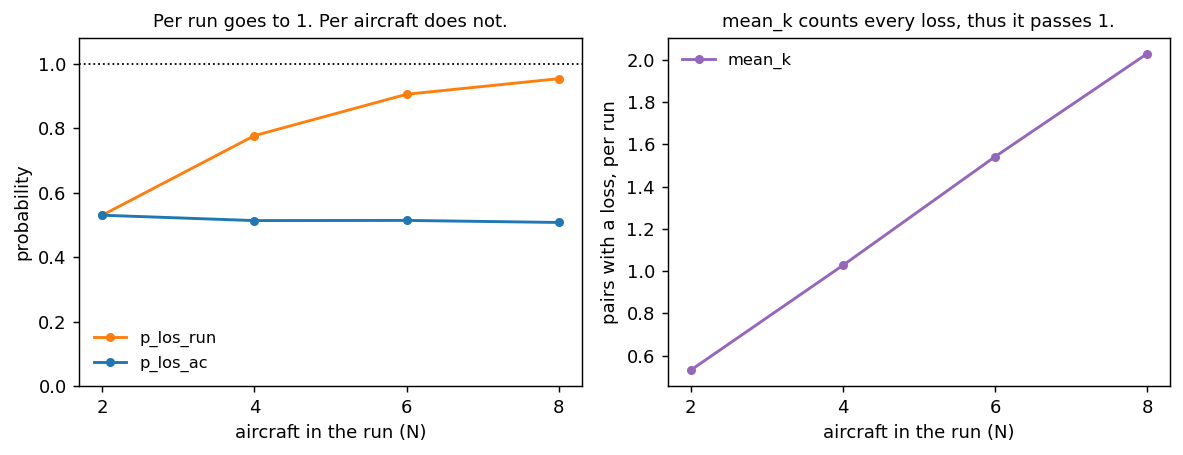

In [9]:
n, run_rate, ac_rate, k_rate = np.array(rows).T

fig, (ax, ax_k) = plt.subplots(1, 2, figsize=(9.2, 3.6))

ax.plot(n, run_rate, marker="o", ms=4, lw=1.6, color="tab:orange", label="p_los_run")
ax.plot(n, ac_rate, marker="o", ms=4, lw=1.6, color="tab:blue", label="p_los_ac")
ax.axhline(1.0, color="k", lw=1.0, ls=":")
ax.set_xlabel("aircraft in the run (N)")
ax.set_ylabel("probability")
ax.set_ylim(0, 1.08)
ax.set_xticks(n)
ax.set_title("Per run goes to 1. Per aircraft does not.", fontsize=10)
ax.legend(frameon=False, fontsize=9)

ax_k.plot(n, k_rate, marker="o", ms=4, lw=1.6, color="tab:purple", label="mean_k")
ax_k.set_xlabel("aircraft in the run (N)")
ax_k.set_ylabel("pairs with a loss, per run")
ax_k.set_xticks(n)
ax_k.set_title("mean_k counts every loss, thus it passes 1.", fontsize=10)
ax_k.legend(frameon=False, fontsize=9)

fig.tight_layout()
plt.show()

**What the figure shows.**

`p_los_run` increases from 0.53 to 0.95. It moves to 1 because a run fails if **any** pair fails.
More pairs give more chances to fail. The value shows a more dangerous airspace. But the risk to
each aircraft does not change.

`p_los_ac` stays near 0.51. Each aircraft keeps the same risk, thus the value stays flat. This is
the correct behaviour.

`mean_k` increases in a straight line. It counts every pair that fails, thus it is a **frequency**
and not a probability. It can be more than 1.

**Why this matters.** When `p_los_run` is near 1, it cannot compare two resolvers. A good resolver
and a bad resolver both give a value near 1. `p_los_ac` and `mean_k` continue to show a difference.
A dense airspace is exactly where you must measure that difference.

## Summary

| | `p_los_run` | `p_los_ac` | `mean_k` |
|---|---|---|---|
| Counts | runs with a loss | aircraft with a loss | pairs with a loss |
| Divides by | the runs | the aircraft that fly | the runs |
| Range | 0 to 1 | 0 to 1 | 0 upwards |
| At N = 2 | the same | the same | the same |
| In a large fleet | goes to 1 | stays stable | increases |

Use `p_los_ac` to compare fleets of different sizes. Use `mean_k` to count how much loss occurs.
Use `p_los_run` when you must know if a run is clean.

`K` counts pairs and `A` counts aircraft. An aircraft in two losing pairs adds 2 to `K`, but it
adds only 1 to `A`. The multiplicity therefore stays in `K`.

At two aircraft all three values are one number. Every pairwise result therefore stays the same.